# Case de Crédito: Modelo Preditivo de Inadimplência (LightGBM)

Este notebook apresenta a solução ponta a ponta para a construção de um modelo de Credit Score/Inadimplência. 
O pipeline contempla:
1. Carregamento e tratamento dos dados.
2. Construção da variável resposta (`TARGET`) com base no atraso de pagamento ($\ge 5$ dias).
3. Engenharia de Features financeiras e temporais.
4. Validação Out-Of-Time (OOT) na última safra.
5. Treinamento final e exportação das predições.
6. Avaliação gráfica da performance do modelo.

In [1]:
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregamento e Pré-processamento dos Dados
Nesta etapa, carregamos as bases cadastrais, de comportamento e de pagamentos, além de realizar a conversão de datas e criação do `TARGET`.

In [2]:
# Carregamento robusto autodetectando separadores
df_cadastral = pd.read_csv(
    "../data/base_cadastral.csv", sep=None, engine="python"
)
df_info = pd.read_csv("../data/base_info.csv", sep=None, engine="python")
df_dev = pd.read_csv(
    "../data/base_pagamentos_desenvolvimento.csv", sep=None, engine="python"
)
df_test = pd.read_csv(
    "../data/base_pagamentos_teste.csv", sep=None, engine="python"
)

# Limpeza de espaços nos nomes das colunas
for df in [df_cadastral, df_info, df_dev, df_test]:
    df.columns = df.columns.str.strip()

# Conversão de colunas de data
df_cadastral["DATA_CADASTRO"] = pd.to_datetime(df_cadastral["DATA_CADASTRO"])

for df in [df_dev, df_test]:
    df["DATA_EMISSAO_DOCUMENTO"] = pd.to_datetime(
        df["DATA_EMISSAO_DOCUMENTO"]
    )
    df["DATA_VENCIMENTO"] = pd.to_datetime(df["DATA_VENCIMENTO"])
    df["SAFRA_REF_DT"] = pd.to_datetime(df["SAFRA_REF"])

df_dev["DATA_PAGAMENTO"] = pd.to_datetime(df_dev["DATA_PAGAMENTO"])

# Definição de Inadimplência: Atraso >= 5 dias ou Pagamento Nulo
dias_atraso = (df_dev["DATA_PAGAMENTO"] - df_dev["DATA_VENCIMENTO"]).dt.days
df_dev["TARGET"] = np.where(
    (dias_atraso >= 5) | (df_dev["DATA_PAGAMENTO"].isna()), 1, 0
)

print("Distribuição da Variável Target (Desenvolvimento):")
print(df_dev["TARGET"].value_counts(normalize=True))

Distribuição da Variável Target (Desenvolvimento):
TARGET
0    0.92978
1    0.07022
Name: proportion, dtype: float64


## 2. Engenharia de Features (Feature Engineering)
Criação de rácios financeiros, cálculo de prazos de pagamento, tempo de relacionamento do cliente e encoding de variáveis categóricas.

In [3]:
def construir_features(df_pagamentos, df_cad, df_inf):
    df = df_pagamentos.merge(df_cad, on="ID_CLIENTE", how="left")
    df = df.merge(df_inf, on=["ID_CLIENTE", "SAFRA_REF"], how="left")

    # Preenchimento de nulos
    df["RENDA_MES_ANTERIOR"] = df["RENDA_MES_ANTERIOR"].fillna(0)
    df["NO_FUNCIONARIOS"] = df["NO_FUNCIONARIOS"].fillna(0)

    # Ratios e métricas financeiras
    df["RATIO_VALOR_RENDA"] = df["VALOR_A_PAGAR"] / (
        df["RENDA_MES_ANTERIOR"] + 1
    )
    df["RENDA_POR_FUNC"] = df["RENDA_MES_ANTERIOR"] / (
        df["NO_FUNCIONARIOS"] + 1
    )

    # Prazos e tempo de relacionamento
    df["PRAZO_PAGAMENTO_DIAS"] = (
        df["DATA_VENCIMENTO"] - df["DATA_EMISSAO_DOCUMENTO"]
    ).dt.days
    df["TEMPO_RELACIONAMENTO_DIAS"] = (
        df["SAFRA_REF_DT"] - df["DATA_CADASTRO"]
    ).dt.days

    # Indicador Pessoa Física / Jurídica
    df["FLAG_PF_NUM"] = df["FLAG_PF"].apply(
        lambda x: 1 if str(x).upper() == "X" else 0
    )

    # Conversão de categóricas para o LightGBM
    cat_cols = [
        "DDD",
        "SEGMENTO_INDUSTRIAL",
        "DOMINIO_EMAIL",
        "PORTE",
        "CEP_2_DIG",
    ]
    for c in cat_cols:
        df[c] = df[c].astype("category")

    return df


# Aplicação das transformações
df_dev_feat = construir_features(df_dev, df_cadastral, df_info)
df_test_feat = construir_features(df_test, df_cadastral, df_info)

features = [
    "VALOR_A_PAGAR",
    "TAXA",
    "RENDA_MES_ANTERIOR",
    "NO_FUNCIONARIOS",
    "RATIO_VALOR_RENDA",
    "RENDA_POR_FUNC",
    "PRAZO_PAGAMENTO_DIAS",
    "TEMPO_RELACIONAMENTO_DIAS",
    "FLAG_PF_NUM",
    "DDD",
    "SEGMENTO_INDUSTRIAL",
    "DOMINIO_EMAIL",
    "PORTE",
    "CEP_2_DIG",
]

print(f"Total de features selecionadas: {len(features)}")

Total de features selecionadas: 14


## 3. Validação Out-Of-Time (OOT)
Separamos a **última safra disponível** no conjunto de desenvolvimento para validação temporariamente desalinhada do treino, simulando a aplicação do modelo em produção no ambiente real.

In [4]:
safras = sorted(df_dev_feat["SAFRA_REF"].unique())
safra_validacao = safras[-1]

df_train = df_dev_feat[df_dev_feat["SAFRA_REF"] != safra_validacao]
df_val = df_dev_feat[df_dev_feat["SAFRA_REF"] == safra_validacao]

X_tr, y_tr = df_train[features], df_train["TARGET"]
X_va, y_va = df_val[features], df_val["TARGET"]

# Modelo de Validação OOT
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

preds_val = model.predict_proba(X_va)[:, 1]

print(f"=== RESULTADOS DA VALIDAÇÃO OOT ===")
print(f"Safra de Validação: {safra_validacao}")
print(f"ROC-AUC Score: {roc_auc_score(y_va, preds_val):.4f}")
print(f"Log-Loss Score: {log_loss(y_va, preds_val):.4f}")

[LightGBM] [Info] Number of positive: 5291, number of negative: 69610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 74901, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.070640 -> initscore=-2.576901
[LightGBM] [Info] Start training from score -2.576901
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

## 4. Retreino Final e Geração de Submissão
Treinamos o modelo final utilizando **todo o histórico de desenvolvimento** com o número ideal de estimadores encontrado na validação e aplicamos o scoring no conjunto de teste.

In [5]:
final_model = lgb.LGBMClassifier(
    n_estimators=model.best_iteration_ or 300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
final_model.fit(df_dev_feat[features], df_dev_feat["TARGET"])

# Predição das probabilidades para a base de Teste
df_test_feat["PROBABILIDADE_INADIMPLENCIA"] = final_model.predict_proba(
    df_test_feat[features]
)[:, 1]

# Gerar arquivo de submissão
submissao = df_test_feat[
    ["ID_CLIENTE", "SAFRA_REF", "PROBABILIDADE_INADIMPLENCIA"]
]
submissao.to_csv("submissao_case.csv", index=False)

print("Arquivo 'submissao_case.csv' gerado com sucesso!")
submissao.head()

[LightGBM] [Info] Number of positive: 5436, number of negative: 71978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1761
[LightGBM] [Info] Number of data points in the train set: 77414, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.070220 -> initscore=-2.583317
[LightGBM] [Info] Start training from score -2.583317
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.001982
1,274692171162531764,2021-07,0.026609
2,274692171162531764,2021-07,0.026411
3,274692171162531764,2021-07,0.026411
4,465309249432033993,2021-07,0.026214


## 5. Visualização e Diagnóstico do Modelo
Geração dos gráficos para análise detalhada do modelo treinado.

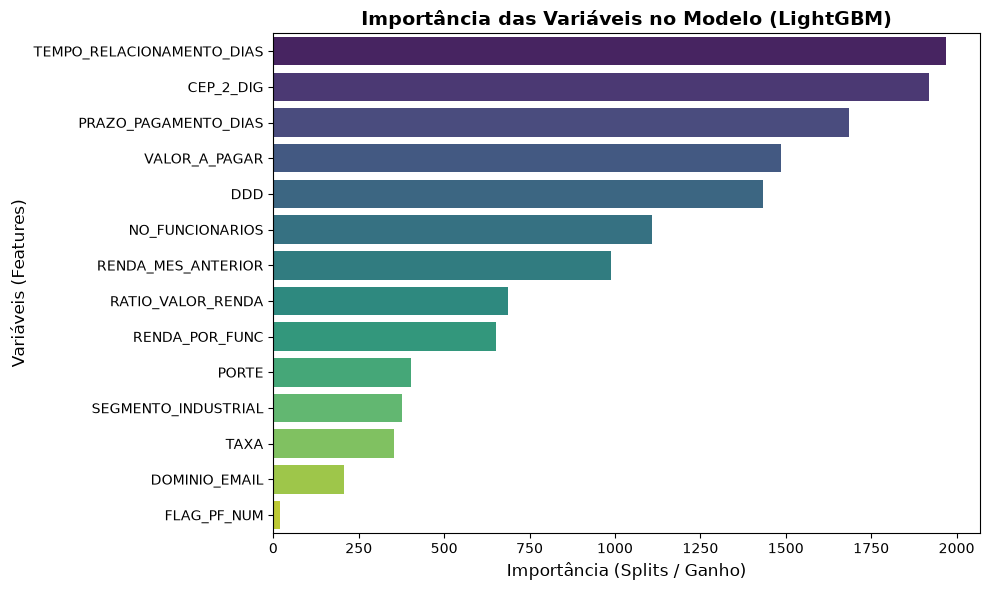

In [6]:
feature_importances = pd.DataFrame({
    "feature": features,
    "importance": final_model.feature_importances_,
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importances, x="importance", y="feature", palette="viridis"
)
plt.title(
    "Importância das Variáveis no Modelo (LightGBM)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Importância (Splits / Ganho)", fontsize=12)
plt.ylabel("Variáveis (Features)", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

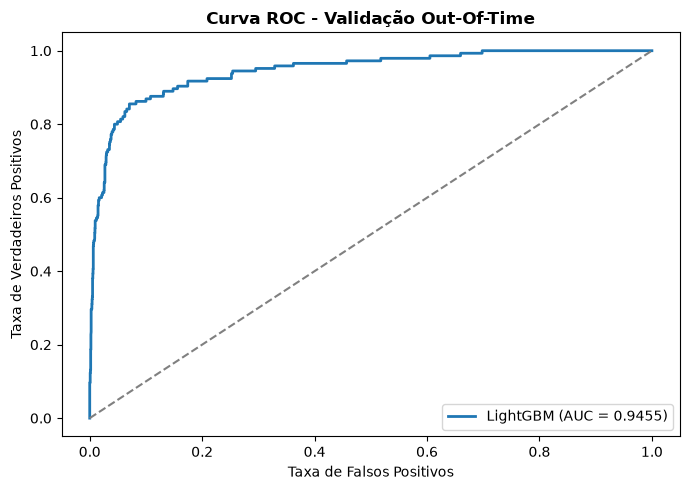

In [7]:
fpr, tpr, _ = roc_curve(y_va, preds_val)
auc_val = roc_auc_score(y_va, preds_val)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    color="#1f77b4",
    lw=2,
    label=f"LightGBM (AUC = {auc_val:.4f})",
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("Curva ROC - Validação Out-Of-Time", fontweight="bold")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=300)
plt.show()

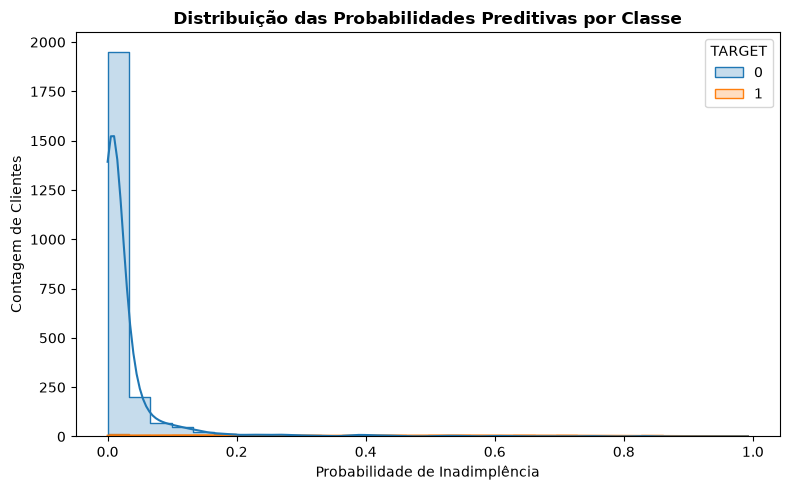

In [8]:
df_val_plot = df_val.copy()
df_val_plot["PROBABILIDADE_INADIMPLENCIA"] = preds_val

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_val_plot,
    x="PROBABILIDADE_INADIMPLENCIA",
    hue="TARGET",
    bins=30,
    kde=True,
    element="step",
)
plt.title(
    "Distribuição das Probabilidades Preditivas por Classe", fontweight="bold"
)
plt.xlabel("Probabilidade de Inadimplência")
plt.ylabel("Contagem de Clientes")
plt.tight_layout()
plt.savefig("distribuicao_probabilidades.png", dpi=300)
plt.show()

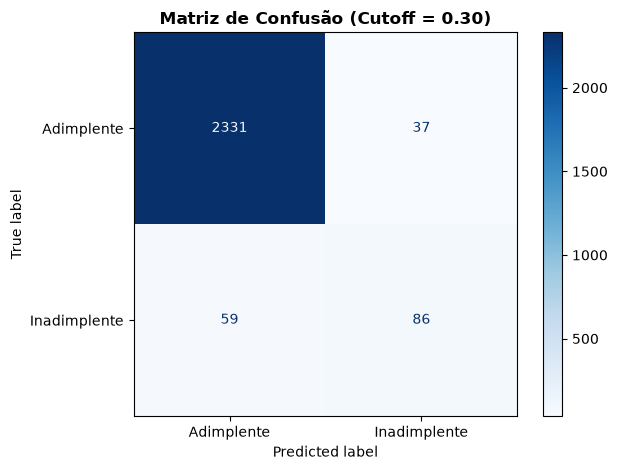

In [9]:
y_pred_class = (preds_val >= 0.30).astype(int)
cm = confusion_matrix(y_va, y_pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Adimplente", "Inadimplente"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão (Cutoff = 0.30)", fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=300)
plt.show()